In [429]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import regex as re

In [430]:
flt = r'\d*\.*\d*e?\+?-?\d*'
error_type = lambda e,t: lambda x: e if x is None else t(x)
i32 = error_type(None, np.int32)
f64_TO = error_type('T.O.', np.float64)

def experiment_to_df(fname, dir='.', ext='.dat', patterns=None, labels_list=None, types_list=None):
    if patterns is None:
        pattern1 = r'(\S*) w:(\S*)\s.*'
        pattern2 = r'T.O.|Done\(\d*\):($flt)\s+#nodes:($flt)\/($flt)\s+P\/D:($flt)\/($flt)\s+Time:($flt)\/($flt)s\s+LIM\?:($flt)\s+Seen:($flt)'.replace(r'$flt', flt)
        patterns = [pattern1, pattern2]
    if labels_list is None:
        labels1 = ['Bench', 'Width' ]
        labels2 = ['Opt', 'nodes1', 'nodes2', 'P', 'D', 'Opt Time', 'Proof Time', None, None]
        labels_list = [labels1, labels2]
    if types_list is None:
        type1 = [str, np.int32]
        type2 = [np.float64, i32, i32, i32, i32, f64_TO, f64_TO, None, None]
        types_list = [type1, type2]

    csv = {}
    with open(f'{dir}/{fname}{ext}') as f:  
        i = 0
        p = False
        for line in f.readlines():
            pattern = patterns[i]
            labels = labels_list[i]
            types = types_list[i]
            i = (i+1) % len(patterns)

            match = re.search(pattern, line)
            if match is None: continue
            groups = match.groups()

            if len(groups) == 0:
                groups = [None] * len(labels)

            for label, match, convert in zip(labels, groups, types):
                if label is None or convert is None: continue

                match = convert(match)
                
                if label in csv: csv[label].append(match)
                else: csv[label] = [match]

    return pd.DataFrame.from_dict(csv, orient='index').transpose()

In [431]:
def experiment_to_df_tsptw(fname, patterns=None, labels_list=None, types_list=None, scale_opt=None, opt_name='Opt'):
    exp = experiment_to_df(fname, patterns=patterns, labels_list=labels_list, types_list=types_list)
    
    if scale_opt is not None: exp[opt_name] /= scale_opt
    return exp

In [432]:
triangular = ['toy/toy1.tw',
 'Dumas/n20w60.003.txt',
 'Dumas/n20w20.005.txt',
 'Dumas/n20w80.005.txt',
 'Dumas/n20w80.001.txt',
 'Dumas/n20w80.003.txt',
 'Dumas/n20w40.002.txt',
 'Dumas/n20w40.005.txt',
 'Dumas/n20w100.002.txt',
 'Dumas/n20w40.004.txt',
 'Dumas/n20w100.001.txt',
 'SolomonPotvinBengio/rc_206.4.txt',
 'SolomonPotvinBengio/rc_202.1.txt',
 'SolomonPotvinBengio/rc_202.3.txt',
 'SolomonPotvinBengio/rc_202.2.txt',
 'SolomonPotvinBengio/rc_206.2.txt',
 'SolomonPotvinBengio/rc_204.1.txt',
 'SolomonPotvinBengio/rc_206.3.txt',
 'SolomonPotvinBengio/rc_206.1.txt',
 'SolomonPotvinBengio/rc_204.3.txt',
 'SolomonPotvinBengio/rc_202.4.txt',
 'SolomonPotvinBengio/rc_204.2.txt',
 'SolomonPotvinBengio/rc_201.1.txt',
 'SolomonPotvinBengio/rc_203.3.txt',
 'SolomonPotvinBengio/rc_205.4.txt',
 'SolomonPotvinBengio/rc_203.2.txt',
 'SolomonPotvinBengio/rc_201.2.txt',
 'SolomonPotvinBengio/rc_207.4.txt',
 'SolomonPotvinBengio/rc_203.1.txt',
 'SolomonPotvinBengio/rc_201.3.txt',
 'SolomonPotvinBengio/rc_205.3.txt',
 'SolomonPotvinBengio/rc_207.1.txt',
 'SolomonPotvinBengio/rc_205.2.txt',
 'SolomonPotvinBengio/rc_203.4.txt',
 'SolomonPotvinBengio/rc_201.4.txt',
 'SolomonPotvinBengio/rc_207.2.txt',
 'SolomonPotvinBengio/rc_207.3.txt',
 'SolomonPotvinBengio/rc_205.1.txt',
 'SolomonPotvinBengio/rc_208.2.txt',
 'SolomonPotvinBengio/rc_208.3.txt',
 'SolomonPotvinBengio/rc_208.1.txt',
 'GendreauDumasExtended/n20w140.004.txt',
 'GendreauDumasExtended/n20w140.005.txt',
 'GendreauDumasExtended/n20w200.002.txt',
 'GendreauDumasExtended/n20w140.002.txt',
 'GendreauDumasExtended/n20w200.001.txt',
 'GendreauDumasExtended/n20w180.003.txt',
 'GendreauDumasExtended/n20w180.001.txt',
 'GendreauDumasExtended/n20w180.005.txt',
 'GendreauDumasExtended/n20w120.005.txt',
 'GendreauDumasExtended/n20w160.003.txt',
 'SolomonPesant/rc201.1',
 'SolomonPesant/rc203.2',
 'SolomonPesant/rc205.0',
 'SolomonPesant/rc201.0',
 'SolomonPesant/rc207.2',
 'SolomonPesant/rc205.1',
 'SolomonPesant/rc206.0',
 'SolomonPesant/rc202.1',
 'SolomonPesant/rc208.1',
 'SolomonPesant/rc204.2',
 'SolomonPesant/rc206.1',
 'SolomonPesant/rc208.0',
 'SolomonPesant/rc202.0',
 'SolomonPesant/rc205.3',
 'SolomonPesant/rc207.0',
 'SolomonPesant/rc201.2',
 'SolomonPesant/rc203.1',
 'SolomonPesant/rc207.1',
 'SolomonPesant/rc205.2',
 'SolomonPesant/rc203.0',
 'SolomonPesant/rc201.3',
 'SolomonPesant/rc202.2',
 'SolomonPesant/rc208.2',
 'SolomonPesant/rc204.0',
 'SolomonPesant/rc202.3',
 'SolomonPesant/rc204.1',
 'SolomonPesant/rc206.2',
 'AFG/rbg040a.tw',
 'AFG/rbg041a.tw',
 'AFG/rbg055a.tw',
 'AFG/rbg021.8.tw',
 'AFG/rbg042a.tw',
 'AFG/rbg021.9.tw',
 'AFG/rbg035a.2.tw',
 'AFG/rbg125a.tw',
 'AFG/rbg092a.tw',
 'AFG/rbg086a.tw',
 'AFG/rbg050a.tw',
 'AFG/rbg193.tw',
 'AFG/rbg021.6.tw',
 'AFG/rbg019d.tw',
 'AFG/rbg017.2.tw',
 'AFG/rbg021.2.tw',
 'AFG/rbg020a.tw',
 'AFG/rbg034a.tw',
 'AFG/rbg035a.tw',
 'AFG/rbg233.tw',
 'AFG/rbg021.3.tw',
 'AFG/rbg019a.tw',
 'AFG/rbg031a.tw',
 'AFG/rbg016b.tw',
 'AFG/rbg132.2.tw',
 'AFG/rbg021.tw',
 'AFG/rbg021.7.tw',
 'AFG/rbg152.3.tw',
 'AFG/rbg027a.tw',
 'AFG/rbg033a.tw',
 'AFG/rbg152.tw',
 'AFG/rbg016a.tw',
 'AFG/rbg019b.tw',
 'AFG/rbg017a.tw',
 'AFG/rbg193.2.tw',
 'AFG/rbg201a.tw',
 'AFG/rbg021.4.tw',
 'AFG/rbg021.5.tw',
 'AFG/rbg132.tw',
 'AFG/rbg017.tw',
 'AFG/rbg038a.tw',
 'AFG/rbg010a.tw',
 'AFG/rbg019c.tw',
 'AFG/rbg172a.tw',
 'AFG/rbg049a.tw',
 'AFG/rbg048a.tw',
 'AFG/rbg050b.tw',
 'AFG/rbg067a.tw',
 'AFG/rbg050c.tw',
 'AFG/rbg233.2.tw']

In [545]:
exp1 = experiment_to_df_tsptw('tsptw_TO_1000s_fixlocal_triangle/tsptw_XFL_1000', scale_opt=10000.0); exp1['Bench'] = exp1['Bench'].str.split('/').str[-2:].str.join('/')
exp2 = experiment_to_df_tsptw('tsptw_TO_1000s_fixlocal_triangle/tsptw_RFL_1000', scale_opt=10000.0); exp2['Bench'] = exp2['Bench'].str.split('/').str[-2:].str.join('/')
exp3 = experiment_to_df_tsptw('tsptw_TO_1000s/tsptw_didp_1000', scale_opt=10000.0, opt_name='Opt_didp', patterns=[r'(\S+)', f't: ({flt}), cost: (\\d+)'], labels_list=[['Bench'],['Proof Time_didp', 'Opt_didp']], types_list=[[str],[np.float64, np.int32]])
exp4 = experiment_to_df_tsptw('tsptw_TO_1000s/tsptw_ddo_1000', labels_list=[['Bench', None],['Opt_ddo', None, None, None, None, None, 'Proof Time_ddo', None, None]]); exp4['Bench'] = exp4['Bench'].str.split('/').str[-2:].str.join('/')

# exp1 = exp1[exp1['Opt'].notna()]
# exp2 = exp2[exp2['Opt'].notna()]

L = 0; R = 1
suffixes = ('_XF', '_RF', '_didp', '_ddo')
merge = pd.merge(exp1, exp2, on=['Bench', 'Width'], how='inner', suffixes=suffixes[:2]).merge(exp3, on=['Bench'], how='inner').merge(exp4, on=['Bench'], how='inner')
final = merge
#final[~final.notna()] = 'T.O.'
final

,Bench,Width,Opt_XF,nodes1_XF,nodes2_XF,P_XF,D_XF,Opt Time_XF,Proof Time_XF,Opt_RF,nodes1_RF,nodes2_RF,P_RF,D_RF,Opt Time_RF,Proof Time_RF,Proof Time_didp,Opt_didp,Opt_ddo,Proof Time_ddo
0,AFG/rbg010a.tw,256,671.0,1,1,0,0,0.001,0.002,671.0,1,1,0,0,0.001,0.001,0.001199,671.0,3840.0,0.004612
1,AFG/rbg010a.tw,1024,671.0,1,1,0,0,0.0,0.001,671.0,1,1,0,0,0.001,0.001,0.001199,671.0,3840.0,0.004612
2,AFG/rbg016a.tw,256,938.0,1,1,0,0,0.002,0.003,938.0,1,1,0,0,0.002,0.002,0.003032,938.0,2596.0,0.013791
3,AFG/rbg016a.tw,1024,938.0,1,1,0,0,0.002,0.003,938.0,1,1,0,0,0.001,0.001,0.003032,938.0,2596.0,0.013791
4,AFG/rbg016b.tw,256,1305.0,3,3,0,0,0.01,0.011,1305.0,1,1,0,0,0.004,0.008,0.026141,1304.0,2094.0,0.054921
5,AFG/rbg016b.tw,1024,1305.0,1,1,0,0,0.047,0.047,1305.0,1,1,0,0,0.019,0.02,0.026141,1304.0,2094.0,0.054921
6,AFG/rbg017.2.tw,256,853.0,1,1,0,0,0.009,0.009,852.0,2,2,0,0,0.003,0.003,0.462106,852.0,2351.0,0.349339
7,AFG/rbg017.2.tw,1024,852.0,1,1,0,0,0.093,0.093,852.0,1,1,0,0,0.012,0.012,0.462106,852.0,2351.0,0.349339
8,AFG/rbg017.tw,256,897.0,1,1,0,0,0.003,0.003,897.0,1,1,0,0,0.001,0.001,0.011686,893.0,2351.0,0.017991
9,AFG/rbg017.tw,1024,893.0,1,1,0,0,0.015,0.015,893.0,1,1,0,0,0.005,0.005,0.011686,893.0,2351.0,0.017991


In [546]:
def average_speedup(L, R):
    global final
    X_times = final[f'Proof Time{suffixes[L]}']
    R_times = final[f'Proof Time{suffixes[R]}']
    X_times = X_times[(final[f'Proof Time{suffixes[L]}'] != 'T.O.') & (final[f'Proof Time{suffixes[R]}'] != 'T.O.')]
    R_times = R_times[(final[f'Proof Time{suffixes[L]}'] != 'T.O.') & (final[f'Proof Time{suffixes[R]}'] != 'T.O.')]

    speedup = X_times / R_times
    # print(speedup)
    speedup = speedup.astype(float).replace(np.inf, np.nan).dropna()

    avg = np.average(speedup)
    print(f'{suffixes[L]}/{suffixes[R]}')
    # if avg >= 1:
    print(f'average speedup = {avg:.2f}')
    #print(f'                = {avg:.2f}')
    # else:
    #     print(f'average slowdown = {1/avg}')
    #     print(f'                 = {1/avg:.2f}')

In [547]:
average_speedup(0,1)
average_speedup(2,1)
average_speedup(3,1)

_XF/_RF
average speedup = 2.25
_didp/_RF
average speedup = 11.59
_ddo/_RF
average speedup = 16.09


In [548]:
def TO_solves(L,R):
    X_TO = merge[(merge[f'Proof Time{suffixes[L]}']=='T.O.') & (merge[f'Proof Time{suffixes[R]}']!='T.O.') & (merge[f'Proof Time{suffixes[R]}'].notna()) & (merge[f'Proof Time{suffixes[L]}'].notna())]
    R_TO = merge[(merge[f'Proof Time{suffixes[L]}']!='T.O.') & (merge[f'Proof Time{suffixes[R]}']=='T.O.') & (merge[f'Proof Time{suffixes[R]}'].notna()) & (merge[f'Proof Time{suffixes[L]}'].notna())]
    print(f'# where {suffixes[L]} TOs, {suffixes[R]} solves: {len(X_TO)}')
    print(f'# where {suffixes[R]} TOs, {suffixes[L]} solves: {len(R_TO)}\n')
TO_solves(0,1)
TO_solves(1,2)
TO_solves(1,3)

# where _XF TOs, _RF solves: 0
# where _RF TOs, _XF solves: 0

# where _RF TOs, _didp solves: 2
# where _didp TOs, _RF solves: 0

# where _RF TOs, _ddo solves: 0
# where _ddo TOs, _RF solves: 0



In [549]:
print(f'rows where Opt{suffixes[L]} and Opt{suffixes[R]} disagree:')
final[final[f'Opt{suffixes[L]}'].notna() & final[f'Opt{suffixes[R]}'].notna() & (final[f'Opt{suffixes[L]}'] != final[f'Opt{suffixes[R]}'])]

rows where Opt_XF and Opt_RF disagree:


,Bench,Width,Opt_XF,nodes1_XF,nodes2_XF,P_XF,D_XF,Opt Time_XF,Proof Time_XF,Opt_RF,nodes1_RF,nodes2_RF,P_RF,D_RF,Opt Time_RF,Proof Time_RF,Proof Time_didp,Opt_didp,Opt_ddo,Proof Time_ddo
6,AFG/rbg017.2.tw,256,853.0,1,1,0,0,0.009,0.009,852.0,2,2,0,0,0.003,0.003,0.462106,852.0,2351.0,0.349339


In [550]:
R=2
print(f'rows where Opt{suffixes[L]} and Opt{suffixes[R]} disagree:')
final[final[f'Opt{suffixes[L]}'].notna() & final[f'Opt{suffixes[R]}'].notna() & (final[f'Opt{suffixes[L]}'] != final[f'Opt{suffixes[R]}'])]

rows where Opt_XF and Opt_didp disagree:


,Bench,Width,Opt_XF,nodes1_XF,nodes2_XF,P_XF,D_XF,Opt Time_XF,Proof Time_XF,Opt_RF,nodes1_RF,nodes2_RF,P_RF,D_RF,Opt Time_RF,Proof Time_RF,Proof Time_didp,Opt_didp,Opt_ddo,Proof Time_ddo
4,AFG/rbg016b.tw,256,1305.0,3,3,0,0,0.01,0.011,1305.0,1,1,0,0,0.004,0.008,0.026141,1304.0,2094.0,0.054921
5,AFG/rbg016b.tw,1024,1305.0,1,1,0,0,0.047,0.047,1305.0,1,1,0,0,0.019,0.02,0.026141,1304.0,2094.0,0.054921
6,AFG/rbg017.2.tw,256,853.0,1,1,0,0,0.009,0.009,852.0,2,2,0,0,0.003,0.003,0.462106,852.0,2351.0,0.349339
8,AFG/rbg017.tw,256,897.0,1,1,0,0,0.003,0.003,897.0,1,1,0,0,0.001,0.001,0.011686,893.0,2351.0,0.017991


In [551]:
R=3
print(f'rows where Opt{suffixes[L]} and Opt{suffixes[R]} disagree:')
final[final[f'Opt{suffixes[L]}'].notna() & final[f'Opt{suffixes[R]}'].notna() & (final[f'Opt{suffixes[L]}'] != final[f'Opt{suffixes[R]}'])]

rows where Opt_XF and Opt_ddo disagree:


,Bench,Width,Opt_XF,nodes1_XF,nodes2_XF,P_XF,D_XF,Opt Time_XF,Proof Time_XF,Opt_RF,nodes1_RF,nodes2_RF,P_RF,D_RF,Opt Time_RF,Proof Time_RF,Proof Time_didp,Opt_didp,Opt_ddo,Proof Time_ddo
0,AFG/rbg010a.tw,256,671.0,1,1,0,0,0.001,0.002,671.0,1,1,0,0,0.001,0.001,0.001199,671.0,3840.0,0.004612
1,AFG/rbg010a.tw,1024,671.0,1,1,0,0,0.0,0.001,671.0,1,1,0,0,0.001,0.001,0.001199,671.0,3840.0,0.004612
2,AFG/rbg016a.tw,256,938.0,1,1,0,0,0.002,0.003,938.0,1,1,0,0,0.002,0.002,0.003032,938.0,2596.0,0.013791
3,AFG/rbg016a.tw,1024,938.0,1,1,0,0,0.002,0.003,938.0,1,1,0,0,0.001,0.001,0.003032,938.0,2596.0,0.013791
4,AFG/rbg016b.tw,256,1305.0,3,3,0,0,0.01,0.011,1305.0,1,1,0,0,0.004,0.008,0.026141,1304.0,2094.0,0.054921
5,AFG/rbg016b.tw,1024,1305.0,1,1,0,0,0.047,0.047,1305.0,1,1,0,0,0.019,0.02,0.026141,1304.0,2094.0,0.054921
6,AFG/rbg017.2.tw,256,853.0,1,1,0,0,0.009,0.009,852.0,2,2,0,0,0.003,0.003,0.462106,852.0,2351.0,0.349339
7,AFG/rbg017.2.tw,1024,852.0,1,1,0,0,0.093,0.093,852.0,1,1,0,0,0.012,0.012,0.462106,852.0,2351.0,0.349339
8,AFG/rbg017.tw,256,897.0,1,1,0,0,0.003,0.003,897.0,1,1,0,0,0.001,0.001,0.011686,893.0,2351.0,0.017991
9,AFG/rbg017.tw,1024,893.0,1,1,0,0,0.015,0.015,893.0,1,1,0,0,0.005,0.005,0.011686,893.0,2351.0,0.017991


In [552]:
L=2
R=3
print(f'rows where Opt{suffixes[L]} and Opt{suffixes[R]} disagree:')
final[final[f'Opt{suffixes[L]}'].notna() & final[f'Opt{suffixes[R]}'].notna() & (final[f'Opt{suffixes[L]}'] != final[f'Opt{suffixes[R]}'])]

rows where Opt_didp and Opt_ddo disagree:


,Bench,Width,Opt_XF,nodes1_XF,nodes2_XF,P_XF,D_XF,Opt Time_XF,Proof Time_XF,Opt_RF,nodes1_RF,nodes2_RF,P_RF,D_RF,Opt Time_RF,Proof Time_RF,Proof Time_didp,Opt_didp,Opt_ddo,Proof Time_ddo
0,AFG/rbg010a.tw,256,671.0,1,1,0,0,0.001,0.002,671.0,1,1,0,0,0.001,0.001,0.001199,671.0,3840.0,0.004612
1,AFG/rbg010a.tw,1024,671.0,1,1,0,0,0.0,0.001,671.0,1,1,0,0,0.001,0.001,0.001199,671.0,3840.0,0.004612
2,AFG/rbg016a.tw,256,938.0,1,1,0,0,0.002,0.003,938.0,1,1,0,0,0.002,0.002,0.003032,938.0,2596.0,0.013791
3,AFG/rbg016a.tw,1024,938.0,1,1,0,0,0.002,0.003,938.0,1,1,0,0,0.001,0.001,0.003032,938.0,2596.0,0.013791
4,AFG/rbg016b.tw,256,1305.0,3,3,0,0,0.01,0.011,1305.0,1,1,0,0,0.004,0.008,0.026141,1304.0,2094.0,0.054921
5,AFG/rbg016b.tw,1024,1305.0,1,1,0,0,0.047,0.047,1305.0,1,1,0,0,0.019,0.02,0.026141,1304.0,2094.0,0.054921
6,AFG/rbg017.2.tw,256,853.0,1,1,0,0,0.009,0.009,852.0,2,2,0,0,0.003,0.003,0.462106,852.0,2351.0,0.349339
7,AFG/rbg017.2.tw,1024,852.0,1,1,0,0,0.093,0.093,852.0,1,1,0,0,0.012,0.012,0.462106,852.0,2351.0,0.349339
8,AFG/rbg017.tw,256,897.0,1,1,0,0,0.003,0.003,897.0,1,1,0,0,0.001,0.001,0.011686,893.0,2351.0,0.017991
9,AFG/rbg017.tw,1024,893.0,1,1,0,0,0.015,0.015,893.0,1,1,0,0,0.005,0.005,0.011686,893.0,2351.0,0.017991


In [553]:
def cum_plot(df, column, log=False, ep=1e-6, sort_by=0):
    s = [suffix for suffix in suffixes if (f'{column}{suffix}' in df.columns)]
    for suffix in s:
        df = df[df[f'{column}{suffix}'] != 'T.O.']
    print(df['Bench'])
    Ys = np.array([np.cumsum(df[f'{column}{suffix}']) for suffix in s])
    if log:
        Ys += ep
        plt.yscale('log')

    X = np.arange(Ys.shape[1])
    plt.plot(X, Ys.T, label=[f'{column}{suffix}' for suffix in s])
    plt.legend()
    plt.show()

0            AFG/rbg010a.tw
1            AFG/rbg010a.tw
2            AFG/rbg016a.tw
3            AFG/rbg016a.tw
4            AFG/rbg016b.tw
5            AFG/rbg016b.tw
6           AFG/rbg017.2.tw
7           AFG/rbg017.2.tw
8             AFG/rbg017.tw
9             AFG/rbg017.tw
10           AFG/rbg017a.tw
11           AFG/rbg017a.tw
12           AFG/rbg019a.tw
13           AFG/rbg019a.tw
14           AFG/rbg019b.tw
15           AFG/rbg019b.tw
16           AFG/rbg019c.tw
17           AFG/rbg019c.tw
18           AFG/rbg019d.tw
19           AFG/rbg019d.tw
20           AFG/rbg020a.tw
21           AFG/rbg020a.tw
22    Dumas/n100w20.001.txt
23    Dumas/n100w20.001.txt
Name: Bench, dtype: object


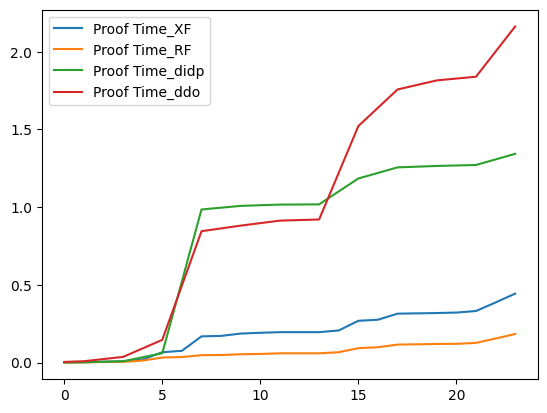

In [554]:
cum_plot(final, 'Proof Time')

0            AFG/rbg010a.tw
1            AFG/rbg010a.tw
2            AFG/rbg016a.tw
3            AFG/rbg016a.tw
4            AFG/rbg016b.tw
5            AFG/rbg016b.tw
6           AFG/rbg017.2.tw
7           AFG/rbg017.2.tw
8             AFG/rbg017.tw
9             AFG/rbg017.tw
10           AFG/rbg017a.tw
11           AFG/rbg017a.tw
12           AFG/rbg019a.tw
13           AFG/rbg019a.tw
14           AFG/rbg019b.tw
15           AFG/rbg019b.tw
16           AFG/rbg019c.tw
17           AFG/rbg019c.tw
18           AFG/rbg019d.tw
19           AFG/rbg019d.tw
20           AFG/rbg020a.tw
21           AFG/rbg020a.tw
22    Dumas/n100w20.001.txt
23    Dumas/n100w20.001.txt
Name: Bench, dtype: object


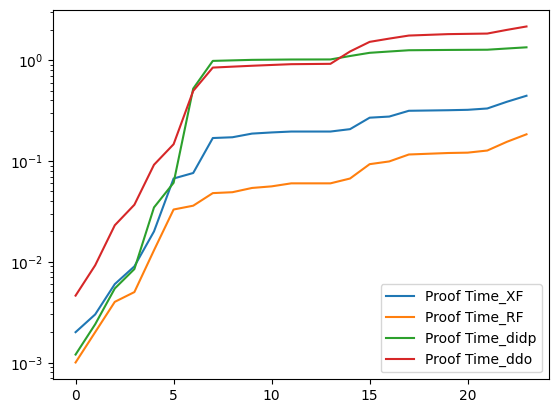

In [555]:
cum_plot(final, 'Proof Time', log=True)

0                             AFG/rbg010a.tw
1                             AFG/rbg010a.tw
2                             AFG/rbg016a.tw
3                             AFG/rbg016a.tw
4                             AFG/rbg016b.tw
5                             AFG/rbg016b.tw
6                            AFG/rbg017.2.tw
7                            AFG/rbg017.2.tw
8                              AFG/rbg017.tw
9                              AFG/rbg017.tw
10                            AFG/rbg017a.tw
11                            AFG/rbg017a.tw
12                            AFG/rbg019a.tw
13                            AFG/rbg019a.tw
14                            AFG/rbg019b.tw
15                            AFG/rbg019b.tw
16                            AFG/rbg019c.tw
17                            AFG/rbg019c.tw
18                            AFG/rbg019d.tw
19                            AFG/rbg019d.tw
20                            AFG/rbg020a.tw
21                            AFG/rbg020a.tw
22        

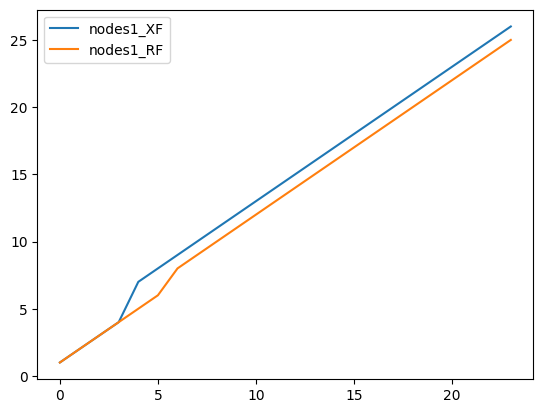

In [556]:
cum_plot(final, 'nodes1')

0                             AFG/rbg010a.tw
1                             AFG/rbg010a.tw
2                             AFG/rbg016a.tw
3                             AFG/rbg016a.tw
4                             AFG/rbg016b.tw
5                             AFG/rbg016b.tw
6                            AFG/rbg017.2.tw
7                            AFG/rbg017.2.tw
8                              AFG/rbg017.tw
9                              AFG/rbg017.tw
10                            AFG/rbg017a.tw
11                            AFG/rbg017a.tw
12                            AFG/rbg019a.tw
13                            AFG/rbg019a.tw
14                            AFG/rbg019b.tw
15                            AFG/rbg019b.tw
16                            AFG/rbg019c.tw
17                            AFG/rbg019c.tw
18                            AFG/rbg019d.tw
19                            AFG/rbg019d.tw
20                            AFG/rbg020a.tw
21                            AFG/rbg020a.tw
22        

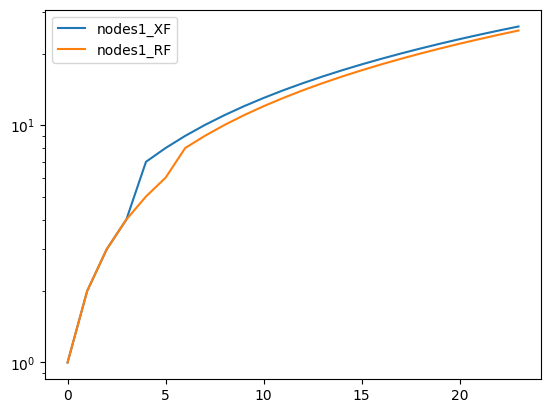

In [557]:
cum_plot(final, 'nodes1', log=True)

In [558]:
def valid_benches(exp, prefix='../data/tsptw'):
    return ' '.join([f'{prefix}/{x}' for x in exp1['Bench'].drop_duplicates()])

In [559]:
exp = experiment_to_df_tsptw('tsptw_TO_1000s_fixlocal/tsptw_RFL_1000', scale_opt=10000.0); exp['Bench'] = exp['Bench'].str.split('/').str[-2:].str.join('/')
valid_benches(exp, prefix='./resources/tsptw')

'./resources/tsptw/AFG/rbg010a.tw ./resources/tsptw/AFG/rbg016a.tw ./resources/tsptw/AFG/rbg016b.tw ./resources/tsptw/AFG/rbg017.2.tw ./resources/tsptw/AFG/rbg017.tw ./resources/tsptw/AFG/rbg017a.tw ./resources/tsptw/AFG/rbg019a.tw ./resources/tsptw/AFG/rbg019b.tw ./resources/tsptw/AFG/rbg019c.tw ./resources/tsptw/AFG/rbg019d.tw ./resources/tsptw/AFG/rbg020a.tw ./resources/tsptw/AFG/rbg021.2.tw ./resources/tsptw/AFG/rbg021.3.tw ./resources/tsptw/AFG/rbg021.4.tw ./resources/tsptw/AFG/rbg021.5.tw ./resources/tsptw/AFG/rbg021.6.tw ./resources/tsptw/AFG/rbg021.7.tw ./resources/tsptw/AFG/rbg021.8.tw ./resources/tsptw/AFG/rbg021.9.tw ./resources/tsptw/AFG/rbg021.tw ./resources/tsptw/AFG/rbg027a.tw ./resources/tsptw/AFG/rbg031a.tw ./resources/tsptw/AFG/rbg033a.tw ./resources/tsptw/AFG/rbg034a.tw ./resources/tsptw/AFG/rbg035a.2.tw ./resources/tsptw/AFG/rbg035a.tw ./resources/tsptw/AFG/rbg038a.tw ./resources/tsptw/AFG/rbg040a.tw ./resources/tsptw/AFG/rbg041a.tw ./resources/tsptw/AFG/rbg042a.tw 

In [560]:
valid_benches(exp1)

'../data/tsptw/AFG/rbg010a.tw ../data/tsptw/AFG/rbg016a.tw ../data/tsptw/AFG/rbg016b.tw ../data/tsptw/AFG/rbg017.2.tw ../data/tsptw/AFG/rbg017.tw ../data/tsptw/AFG/rbg017a.tw ../data/tsptw/AFG/rbg019a.tw ../data/tsptw/AFG/rbg019b.tw ../data/tsptw/AFG/rbg019c.tw ../data/tsptw/AFG/rbg019d.tw ../data/tsptw/AFG/rbg020a.tw ../data/tsptw/AFG/rbg021.2.tw ../data/tsptw/AFG/rbg021.3.tw ../data/tsptw/AFG/rbg021.4.tw ../data/tsptw/AFG/rbg021.5.tw ../data/tsptw/AFG/rbg021.6.tw ../data/tsptw/AFG/rbg021.7.tw ../data/tsptw/AFG/rbg021.8.tw ../data/tsptw/AFG/rbg021.9.tw ../data/tsptw/AFG/rbg021.tw ../data/tsptw/AFG/rbg027a.tw ../data/tsptw/AFG/rbg031a.tw ../data/tsptw/AFG/rbg033a.tw ../data/tsptw/AFG/rbg034a.tw ../data/tsptw/AFG/rbg035a.2.tw ../data/tsptw/AFG/rbg035a.tw ../data/tsptw/AFG/rbg038a.tw ../data/tsptw/AFG/rbg040a.tw ../data/tsptw/AFG/rbg041a.tw ../data/tsptw/AFG/rbg042a.tw ../data/tsptw/AFG/rbg048a.tw ../data/tsptw/Dumas/n100w20.001.txt ../data/tsptw/Dumas/n100w20.002.txt ../data/tsptw/Dumas